# Olist Initial Purchase Gradient Boosting

## Project objective

This notebook builds the third baseline classifier for predicting whether a customer makes a repeat purchase within 90 days of their initial purchase. It deliberately keeps the Logistic Regression and Random Forest experiment unchanged: the same PostgreSQL source, complete-case population, eight raw predictors, chronological split, target, and evaluation population.

Gradient Boosting builds decision trees sequentially. Each new small tree focuses on mistakes made by the earlier trees, and their contributions are combined into one prediction. Unlike Random Forest, which grows many independent trees and averages them, Gradient Boosting learns a staged correction process. It is a useful third baseline because it tests whether that different tree-ensemble approach can find useful nonlinear patterns without changing the modeling problem.

In [1]:
# Core libraries handle tabular data, plotting, database access, preprocessing, modeling, and evaluation.
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, precision_recall_curve, auc
)

## Load the same modeling table

The table is read from PostgreSQL without changing it. Using the same prepared customer-level source keeps this algorithm comparison fair.

In [2]:
# Connect to the local database that contains the prepared, customer-level modeling table.
engine = create_engine("postgresql+psycopg2://marcusromeo@localhost:5432/olist_project")
# Load the exact source used by the earlier baselines; no data is written back to PostgreSQL.
df = pd.read_sql("SELECT * FROM customer_initial_purchase_model", engine)
print(f"Loaded {len(df):,} customers and {df.shape[1]} columns.")
df.head()

Loaded 87,008 customers and 13 columns.


,customer_unique_id,repeat_purchase_90d,customer_state,first_order_date,first_order_amount,product_amount,freight_amount,products_ordered,unique_products_ordered,number_of_categories,number_of_sellers,payment_installments,freight_to_order_ratio
0,98af3235f3dc55bc74cb8932c64b3523,No,BA,2018-04-22 14:26:17,125.33,102.90,22.43,1.0,1.0,1.0,1.0,4.0,0.178968
1,494e875bef93610d10c951763389f74e,No,RJ,2017-05-15 12:55:13,77.75,60.08,17.67,1.0,1.0,1.0,1.0,5.0,0.227267
2,3a1aed3a4ca113b4909b06889ecba01b,No,SP,2018-05-14 15:36:23,104.76,89.98,14.78,2.0,1.0,1.0,1.0,1.0,0.141084
3,2ab7fad20e1c4c7747dfc91137b862cf,No,SP,2017-03-19 12:41:44,119.99,99.99,20.00,1.0,1.0,1.0,1.0,2.0,0.166681
4,f714fd5260fc9d9f1b9628afe96e488a,No,RS,2017-11-27 14:54:37,85.92,69.99,15.93,1.0,1.0,1.0,1.0,4.0,0.185405


## Preserve the complete-case modeling population

The previous experiments first exclude customers missing initial-order amount and then remove the one remaining row with any missing value. Repeating those exact steps ensures all three models are trained and tested on the same people.

In [3]:
# Keep the reference filtering order so differences in results come from the algorithm, not a different population.
df_model = df.dropna(subset=["first_order_amount"])
# Use only complete rows because this baseline intentionally does not add an imputation method.
df_final = df_model.dropna().copy()

# Fail early if the source data or filtering changes and would make the comparison inconsistent.
assert df.shape == (87008, 13)
assert df_model.shape == (86351, 13)
assert df_final.shape == (86350, 13)
assert not df_final.isna().any().any()
print(f"Final complete-case population: {len(df_final):,} customers")

Final complete-case population: 86,350 customers


## Define the prediction problem

Every predictor describes the initial purchase. The customer ID and order date are excluded, and no later customer behavior is used, so the model does not receive post-purchase information that could leak the answer.

In [4]:
# These eight first-purchase predictors match the final Logistic Regression and Random Forest feature set.
feature_columns = [
    "customer_state",
    "first_order_amount",
    "freight_to_order_ratio",
    "products_ordered",
    "unique_products_ordered",
    "number_of_categories",
    "number_of_sellers",
    "payment_installments",
]
# This is the outcome to predict, not an input feature.
target_column = "repeat_purchase_90d"
assert len(feature_columns) == 8
assert set(feature_columns).issubset(df_final.columns)
assert target_column in df_final.columns
print(f"Raw predictors ({len(feature_columns)}): {feature_columns}")

Raw predictors (8): ['customer_state', 'first_order_amount', 'freight_to_order_ratio', 'products_ordered', 'unique_products_ordered', 'number_of_categories', 'number_of_sellers', 'payment_installments']


## Create the chronological train/test split

Training on earlier initial purchases and testing on later ones better reflects deployment than a random split. The test set stays untouched until final evaluation.

In [5]:
# Select the same 80th-percentile date as the earlier notebooks, rather than randomly mixing time periods.
cutoff_date = df_final["first_order_date"].sort_values().iloc[int(len(df_final) * 0.80)]
train = df_final[df_final["first_order_date"] <= cutoff_date].copy()
test = df_final[df_final["first_order_date"] > cutoff_date].copy()

# X holds predictors and y holds labels; separating them prevents the target from being passed to the model.
X_train, X_test = train[feature_columns], test[feature_columns]
# Map the stored No/Yes labels to the 0/1 classes expected by scikit-learn.
y_train = train[target_column].map({"No": 0, "Yes": 1})
y_test = test[target_column].map({"No": 0, "Yes": 1})

# Verify the exact cutoff, populations, label counts, and feature-only X matrices used by the reference experiments.
assert cutoff_date == pd.Timestamp("2018-04-24 14:16:45")
assert (len(train), len(test)) == (69081, 17269)
assert y_train.value_counts().to_dict() == {0: 67622, 1: 1459}
assert y_test.value_counts().to_dict() == {0: 17043, 1: 226}
assert list(X_train.columns) == feature_columns
assert list(X_test.columns) == feature_columns
assert not X_train.isna().any().any() and not X_test.isna().any().any()
print(f"Cutoff: {cutoff_date}")
print(f"Train rows: {len(train):,}; target counts: {y_train.value_counts().sort_index().to_dict()}")
print(f"Test rows:  {len(test):,}; target counts: {y_test.value_counts().sort_index().to_dict()}")

Cutoff: 2018-04-24 14:16:45
Train rows: 69,081; target counts: {0: 67622, 1: 1459}
Test rows:  17,269; target counts: {0: 17043, 1: 226}


## Preprocess categorical and numeric features

Gradient Boosting, like Random Forest, learns splits rather than distance-based relationships, so rescaling numeric predictors is not required. Customer state is one-hot encoded so its categories become model-ready indicator columns.

In [6]:
# Keep state separate because it is categorical; the remaining selected predictors are numeric.
categorical_features = ["customer_state"]
numeric_features = [column for column in feature_columns if column not in categorical_features]

# Apply type-specific preparation consistently while leaving numeric values on their original scale for this tree model.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        # One indicator per state lets the model use location without imposing a false numeric ordering.
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
# fit_transform learns categories from training data only, preventing information from the test period leaking into preprocessing.
X_train_processed = preprocessor.fit_transform(X_train)
# transform reuses that learned mapping, so test columns exactly match the training representation.
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
assert X_train_processed.shape[1] == X_test_processed.shape[1] == len(feature_names)
print(f"Processed shapes: train {X_train_processed.shape}, test {X_test_processed.shape}")
print(feature_names)

Processed shapes: train (69081, 34), test (17269, 34)
['numeric__first_order_amount' 'numeric__freight_to_order_ratio'
 'numeric__products_ordered' 'numeric__unique_products_ordered'
 'numeric__number_of_categories' 'numeric__number_of_sellers'
 'numeric__payment_installments' 'categorical__customer_state_AC'
 'categorical__customer_state_AL' 'categorical__customer_state_AM'
 'categorical__customer_state_AP' 'categorical__customer_state_BA'
 'categorical__customer_state_CE' 'categorical__customer_state_DF'
 'categorical__customer_state_ES' 'categorical__customer_state_GO'
 'categorical__customer_state_MA' 'categorical__customer_state_MG'
 'categorical__customer_state_MS' 'categorical__customer_state_MT'
 'categorical__customer_state_PA' 'categorical__customer_state_PB'
 'categorical__customer_state_PE' 'categorical__customer_state_PI'
 'categorical__customer_state_PR' 'categorical__customer_state_RJ'
 'categorical__customer_state_RN' 'categorical__customer_state_RO'
 'categorical__cust

## Fit the Gradient Boosting baseline

This uses scikit-learn defaults except for a fixed random seed. No hyperparameter tuning, cross-validation, class weighting, resampling, threshold change, or new features are introduced; that isolates the algorithm choice.

In [7]:
# random_state=42 makes the model's stochastic training process reproducible across runs.
model = GradientBoostingClassifier(random_state=42)
# Learn only from the processed training data and its known outcomes; the test set remains unseen.
model.fit(X_train_processed, y_train)
model

GradientBoostingClassifier(random_state=42)

## Evaluate training and untouched testing performance

Class predictions use the unchanged default 0.50 threshold. Predicted probabilities are also evaluated because ROC-AUC and PR-AUC measure how well the model ranks customers across thresholds; PR-AUC is particularly useful here because repeat purchasers are rare.

In [8]:
# Keep all requested threshold and ranking metrics in one function so train/test results are calculated identically.
def evaluate_model(y_true, predictions, probabilities):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, probabilities)
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": auc(recall_curve, precision_curve),
        "positive_predictions": int(predictions.sum()),
        "actual_positive_cases": int(y_true.sum()),
    }

# predict returns default-threshold classes; predict_proba supplies class-1 probabilities for ranking metrics.
y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)
y_train_proba = model.predict_proba(X_train_processed)[:, 1]
y_test_proba = model.predict_proba(X_test_processed)[:, 1]

train_metrics = evaluate_model(y_train, y_train_pred, y_train_proba)
test_metrics = evaluate_model(y_test, y_test_pred, y_test_proba)

# The confusion matrix reveals each error type, which accuracy alone can hide with an imbalanced target.
test_confusion = confusion_matrix(y_test, y_test_pred)
print("Test confusion matrix:")
print(test_confusion)
print("\nMetrics at the default 0.50 threshold (ranking metrics use probabilities):")
pd.DataFrame([train_metrics, test_metrics], index=["Training", "Testing"])

Test confusion matrix:
[[17031    12]
 [  226     0]]

Metrics at the default 0.50 threshold (ranking metrics use probabilities):


,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_predictions,actual_positive_cases
Training,0.979387,1.0,0.023989,0.046854,0.664568,0.114710,35,1459
Testing,0.986218,0.0,0.000000,0.000000,0.534891,0.014527,12,226


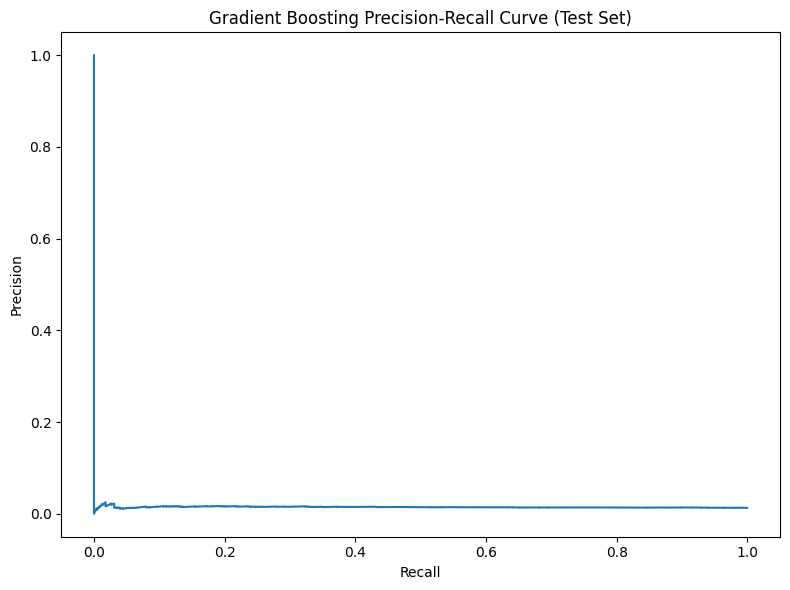

In [9]:
# Plot the requested precision-recall curve for the untouched chronological test set.
test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(test_recall_curve, test_precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Gradient Boosting Precision-Recall Curve (Test Set)")
plt.tight_layout()
plt.show()

## Feature importance

Gradient Boosting provides impurity-based feature importances. They describe model reliance, not causality; can be biased toward certain feature types; do not show the direction of an effect; and deserve extra caution when test performance is weak. State's one-hot columns are summed back into one raw-feature importance for a readable comparison.

,importance
first_order_amount,0.407711
freight_to_order_ratio,0.284410
payment_installments,0.119060
customer_state,0.085047
unique_products_ordered,0.068602
products_ordered,0.030725
number_of_sellers,0.002859
number_of_categories,0.001586


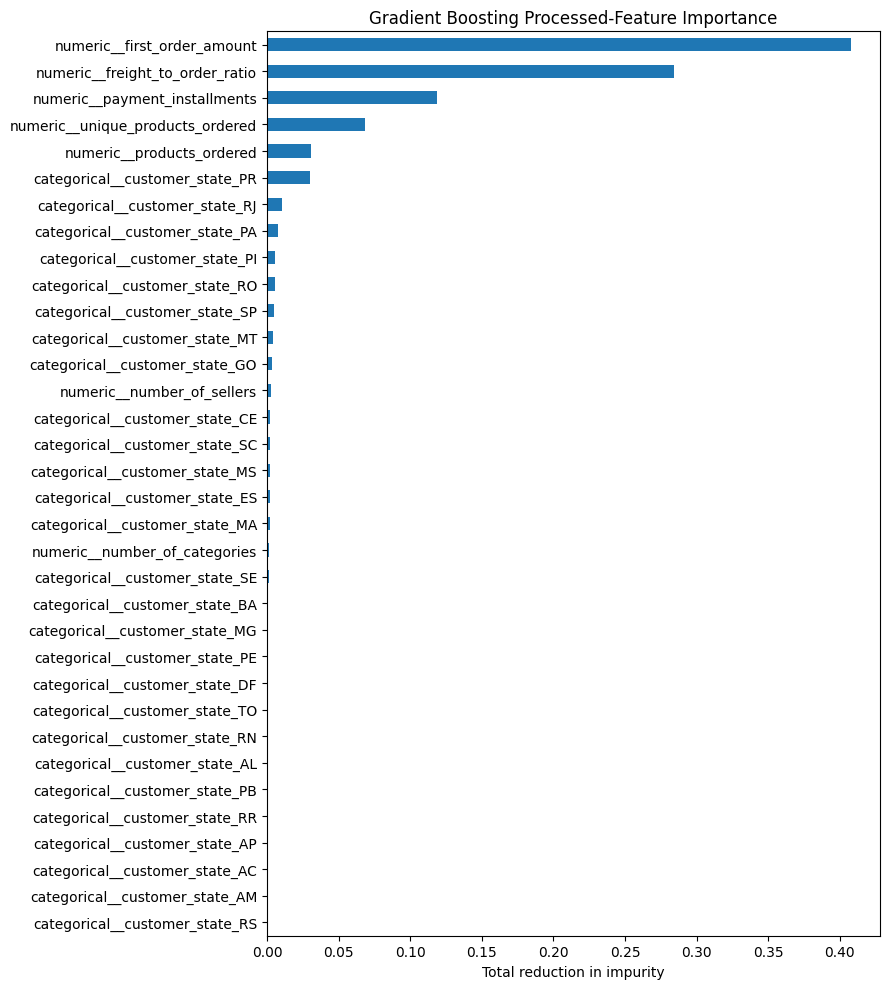

In [10]:
# Match each transformed column to its impurity-based importance from the fitted boosting model.
processed_importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
# Combine all state dummy columns so customer_state can be compared fairly with one-column numeric features.
raw_importance = pd.Series({
    **{column: processed_importance[f"numeric__{column}"] for column in numeric_features},
    "customer_state": processed_importance[
        processed_importance.index.str.startswith("categorical__customer_state_")
    ].sum(),
}).sort_values(ascending=False)
display(raw_importance.rename("importance").to_frame())

processed_importance.sort_values().plot.barh(
    figsize=(9, 10), title="Gradient Boosting Processed-Feature Importance"
)
plt.xlabel("Total reduction in impurity")
plt.tight_layout()
plt.show()

## Compare all three baseline models

The comparison uses the identical untouched test population. Small changes in weak ranking metrics should not be described as meaningful improvements; the practical question is whether the model ranks likely repeat purchasers substantially better than chance and identifies them at the default threshold.

In [11]:
# Store the supplied same-experiment test metrics for the two earlier baselines.
logistic_baseline = {
    "accuracy": 0.98691, "precision": 0.0, "recall": 0.0, "f1": 0.0,
    "roc_auc": 0.5063, "pr_auc": 0.0154,
}
random_forest_baseline = {
    "accuracy": 0.985639, "precision": 0.0, "recall": 0.0, "f1": 0.0,
    "roc_auc": 0.508648, "pr_auc": 0.013461,
}
# Align the same test metrics so only the modeling algorithm differs across columns.
comparison_metrics = list(logistic_baseline)
comparison = pd.DataFrame({
    "Logistic Regression": pd.Series(logistic_baseline),
    "Random Forest": pd.Series(random_forest_baseline),
    "Gradient Boosting": pd.Series({key: test_metrics[key] for key in comparison_metrics}),
})
comparison["GB minus Logistic"] = comparison["Gradient Boosting"] - comparison["Logistic Regression"]
comparison["GB minus RF"] = comparison["Gradient Boosting"] - comparison["Random Forest"]
comparison

,Logistic Regression,Random Forest,Gradient Boosting,GB minus Logistic,GB minus RF
accuracy,0.98691,0.985639,0.986218,-0.000692,0.000579
precision,0.00000,0.000000,0.000000,0.000000,0.000000
recall,0.00000,0.000000,0.000000,0.000000,0.000000
f1,0.00000,0.000000,0.000000,0.000000,0.000000
roc_auc,0.50630,0.508648,0.534891,0.028591,0.026243
pr_auc,0.01540,0.013461,0.014527,-0.000873,0.001066


In [12]:
# Compare training and testing ROC-AUC to assess whether apparent training fit carries forward to later customers.
overfit_gap = train_metrics["roc_auc"] - test_metrics["roc_auc"]
best_prior_roc_auc = max(logistic_baseline["roc_auc"], random_forest_baseline["roc_auc"])
best_prior_pr_auc = max(logistic_baseline["pr_auc"], random_forest_baseline["pr_auc"])

if overfit_gap >= 0.05:
    generalization_verdict = "shows evidence of overfitting because training ranking performance is much stronger than testing"
else:
    generalization_verdict = "shows no large ROC-AUC generalization gap"

if test_metrics["recall"] == 0:
    threshold_verdict = (
        f"made {test_metrics['positive_predictions']} positive predictions, but none corresponded to actual repeat purchasers, so it identified zero true repeat purchasers at the default 0.50 threshold"
    )
else:
    threshold_verdict = "identifies at least some true repeat purchasers at the default 0.50 threshold"

if (test_metrics["roc_auc"] - best_prior_roc_auc > 0.01 and
        test_metrics["pr_auc"] - best_prior_pr_auc > 0.001):
    ranking_verdict = "is materially stronger than both earlier baselines on both ranking metrics"
else:
    ranking_verdict = "is not materially stronger than both earlier baselines; small differences should be treated cautiously"

print(f"Training-to-testing ROC-AUC gap: {overfit_gap:.4f}")
print(f"Gradient Boosting {generalization_verdict}.")
print("Its approximately 0.1297 gap is substantially smaller than Random Forest's approximately 0.4885 gap, but testing performance remains weak.")
print(f"Gradient Boosting {threshold_verdict}.")
print(f"Its ranking performance {ranking_verdict}.")
print("Weak test ranking performance suggests this first-purchase feature set may contain limited usable signal for this task; it does not prove that no predictive signal exists.")

Training-to-testing ROC-AUC gap: 0.1297
Gradient Boosting shows evidence of overfitting because training ranking performance is much stronger than testing.
Its approximately 0.1297 gap is substantially smaller than Random Forest's approximately 0.4885 gap, but testing performance remains weak.
Gradient Boosting made 12 positive predictions, but none corresponded to actual repeat purchasers, so it identified zero true repeat purchasers at the default 0.50 threshold.
Its ranking performance is not materially stronger than both earlier baselines; small differences should be treated cautiously.
Weak test ranking performance suggests this first-purchase feature set may contain limited usable signal for this task; it does not prove that no predictive signal exists.


## Interpretation

Gradient Boosting had a training ROC-AUC of 0.664568 but a test ROC-AUC of 0.534891, a gap of about 0.1297. This is evidence of generalization loss rather than strong performance on later customers. The gap is substantially smaller than Random Forest's approximately 0.4885 train-to-test ROC-AUC gap, so its overfitting is less severe, but its test performance remains weak. At the unchanged 0.50 threshold it made 12 positive test predictions, but none matched the 226 actual repeat purchasers, so it identified zero true repeat purchasers and precision, recall, and F1 were all 0.

Its test ROC-AUC was modestly above Logistic Regression (0.5063) and Random Forest (0.5086), but its PR-AUC of 0.0145 was below Logistic Regression (0.0154) and only slightly above Random Forest (0.0135). These small, mixed differences should not be treated as meaningful improvement. Together, the weak test ranking metrics and threshold results suggest that the current first-purchase features offer limited usable predictive signal for this setup; they do not prove that repeat purchase has no predictive signal.